In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import datasets
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [24]:
def euclidean_distance(x1, x2):
    distance = np.sqrt(np.sum((x1 - x2) ** 2))
    return distance

In [31]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        # calculate euclidean distance
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # get the top 3 / closest 3 k
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [int(self.y_train[i]) for i in k_indices]

        # majority vote (classification) or most common class label
        most_common = Counter(k_nearest_labels).most_common()
        return most_common[0][0]

In [7]:
iris = datasets.load_iris()
X, y = iris.data, iris.target

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [11]:
cmap = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

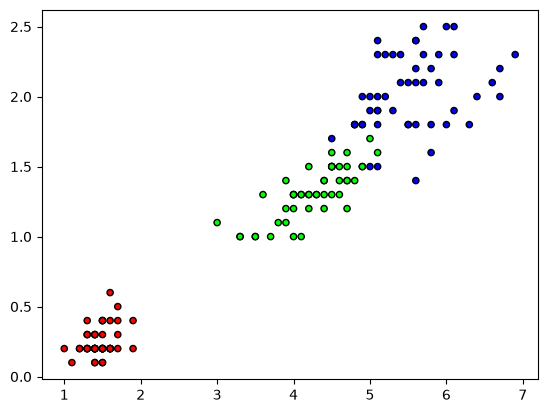

In [12]:
plt.figure()
plt.scatter(X[:,2], X[:,3], c=y, cmap=cmap, edgecolors='k', s=20)
plt.show()

In [32]:
clf = KNN(k=5)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)
print(predictions)

[2, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0]


In [33]:
acc = np.sum(predictions == y_test) / len(y_test)
print(acc)

0.9666666666666667


### 1. Confusion matrix heatmap

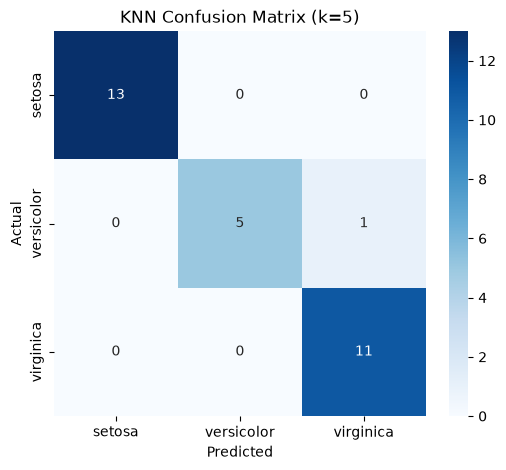

In [35]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix (k=5)')
plt.show()

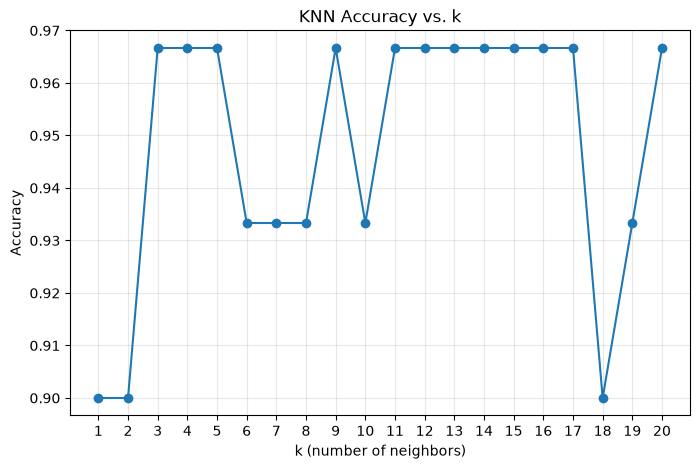

In [36]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    clf_k = KNN(k=k)
    clf_k.fit(X_train, y_train)
    preds_k = clf_k.predict(X_test)
    acc_k = np.sum(preds_k == y_test) / len(y_test)
    accuracies.append(acc_k)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. k')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

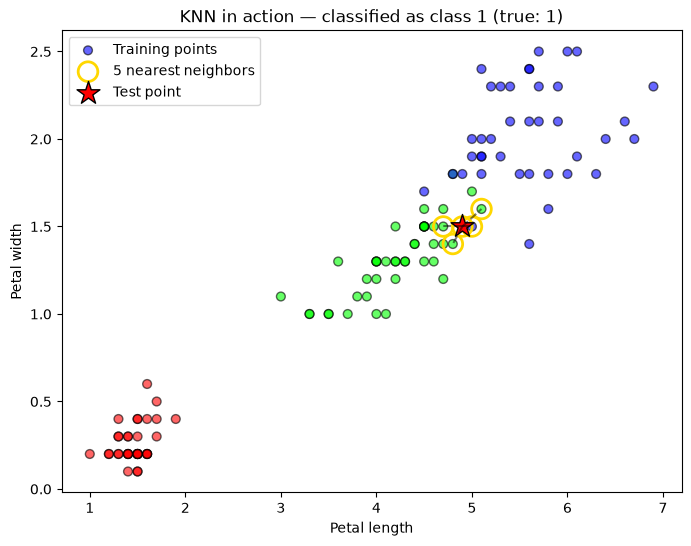

In [38]:
# Use 2 features (petal length & width) so we can plot it
X_train_2d = X_train[:, [2, 3]]
X_test_2d = X_test[:, [2, 3]]

clf_2d = KNN(k=5)
clf_2d.fit(X_train_2d, y_train)

idx = 0  # which test point to visualize
test_point = X_test_2d[idx]

# find its k nearest neighbors (same logic as _predict)
distances = [euclidean_distance(test_point, x_train) for x_train in X_train_2d]
k_indices = np.argsort(distances)[:clf_2d.k]
neighbor_points = X_train_2d[k_indices]

predicted_label = clf_2d.predict(np.array([test_point]))[0]

plt.figure(figsize=(8, 6))
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap,
            edgecolors='k', s=40, alpha=0.6, label='Training points')

for n_point in neighbor_points:
    plt.plot([test_point[0], n_point[0]], [test_point[1], n_point[1]], 'k--', alpha=0.5)

plt.scatter(neighbor_points[:, 0], neighbor_points[:, 1], facecolors='none',
            edgecolors='gold', s=200, linewidths=2, label=f'{clf_2d.k} nearest neighbors')

plt.scatter(test_point[0], test_point[1], c='red', marker='*', s=300,
            edgecolors='k', label='Test point')

plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title(f'KNN in action — classified as class {predicted_label} (true: {y_test[idx]})')
plt.legend()
plt.show()

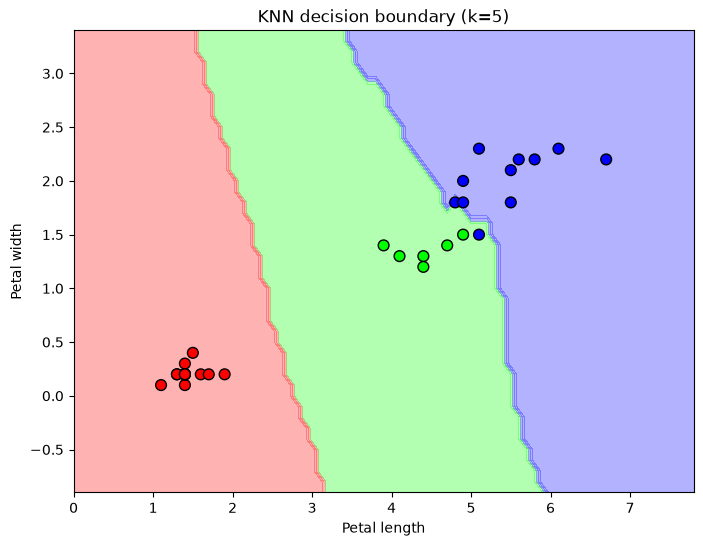

In [39]:
h = 0.1  # mesh step (coarser = faster since your KNN loops in pure Python)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = np.array(clf_2d.predict(grid_points)).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap=cmap,
            edgecolors='k', s=60, label='Test points')
plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('KNN decision boundary (k=5)')
plt.show()